## Load Data and Prepare for Analysis

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Define the two directories
data_paths = {
    "LDA_SVM_subject":   "outputs/ensemble_v2/models-LDA_SVM__weights-baseline_subject__feat-fbcsp__ens-softvote__tune-none__cal-sigmoid",
    "LDA_SVM_RF_global": "outputs/ensemble_v2/models-LDA_SVM_RF__weights-baseline_global__feat-fbcsp__ens-softvote__tune-none__cal-sigmoid",
    "LDA_SVM_RF_subject": "outputs/ensemble_v2/models-LDA_SVM__weights-baseline_subject__feat-fbcsp__ens-stacking__tune-none__cal-sigmoid"
}

all_dfs = {}

for config_name, data_path in data_paths.items():
    print(f"\n{'='*60}")
    print(f"Loading from config: {config_name}")
    print(f"Path: {os.path.abspath(data_path)}")
    print(f"{'='*60}")

    try:
        print("Files found:")
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except FileNotFoundError:
        print(f"  ERROR: Directory not found — {os.path.abspath(data_path)}")
        continue

    dfs = []
    for i in range(1, 10):
        file_name = f"predictions_subject_{i}.csv"
        file_path = os.path.join(data_path, file_name)
        try:
            df = pd.read_csv(file_path)
            df["subject"] = i
            df["config"] = config_name
            dfs.append(df)
            print(f"  Loaded: {file_name}")
        except FileNotFoundError:
            print(f"  MISSING: {file_name}")
        except Exception as e:
            print(f"  ERROR loading {file_name}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        all_dfs[config_name] = combined
        print(f"\n  Combined shape: {combined.shape}")
        display(combined.head())
    else:
        print(f"  No data loaded for config: {config_name}")

# Access individual configs
df_subject = all_dfs.get("LDA_SVM_subject")
df_global  = all_dfs.get("LDA_SVM_RF_global")

# Flat master DataFrame (all rows from both configs)
if all_dfs:
    master_df = pd.concat(all_dfs.values(), ignore_index=True)
    print(f"\nMaster DataFrame shape: {master_df.shape}")
    display(master_df.head())


Loading from config: LDA_SVM_subject
Path: /Users/kevinzhou/Desktop/kev-personal/jr-academy/m.i.n.d/outputs/ensemble_v2/models-LDA_SVM__weights-baseline_subject__feat-fbcsp__ens-softvote__tune-none__cal-sigmoid
Files found:
  - predictions_subject_7.csv
  - predictions_subject_6.csv
  - predictions_subject_4.csv
  - predictions_subject_5.csv
  - predictions_subject_1.csv
  - predictions_subject_2.csv
  - run_summary.csv
  - predictions_subject_3.csv
  - config.json
  - threshold_metrics.csv
  - subject_results.csv
  - predictions_subject_8.csv
  - predictions_subject_9.csv
  Loaded: predictions_subject_1.csv
  Loaded: predictions_subject_2.csv
  Loaded: predictions_subject_3.csv
  Loaded: predictions_subject_4.csv
  Loaded: predictions_subject_5.csv
  Loaded: predictions_subject_6.csv
  Loaded: predictions_subject_7.csv
  Loaded: predictions_subject_8.csv
  Loaded: predictions_subject_9.csv

  Combined shape: (2581, 12)


,subject,trial_index,y_true,ensemble_pred,ensemble_max_prob,lda_pred,svm_pred,p_ens_c0,p_ens_c1,p_ens_c2,p_ens_c3,config
0,1,0,3,2,0.715157,2,3,0.039991,0.016395,0.715157,0.228457,LDA_SVM_subject
1,1,1,2,2,0.717698,2,3,0.010804,0.040689,0.717698,0.230809,LDA_SVM_subject
2,1,2,1,2,0.464111,2,1,0.204888,0.290255,0.464111,0.040746,LDA_SVM_subject
3,1,3,0,0,0.824069,0,0,0.824069,0.021788,0.049746,0.104396,LDA_SVM_subject
4,1,4,0,0,0.684111,0,2,0.684111,0.028764,0.169879,0.117247,LDA_SVM_subject



Loading from config: LDA_SVM_RF_global
Path: /Users/kevinzhou/Desktop/kev-personal/jr-academy/m.i.n.d/outputs/ensemble_v2/models-LDA_SVM_RF__weights-baseline_global__feat-fbcsp__ens-softvote__tune-none__cal-sigmoid
Files found:
  - predictions_subject_7.csv
  - predictions_subject_6.csv
  - predictions_subject_4.csv
  - predictions_subject_5.csv
  - predictions_subject_1.csv
  - predictions_subject_2.csv
  - run_summary.csv
  - predictions_subject_3.csv
  - config.json
  - threshold_metrics_debounced.csv
  - threshold_metrics.csv
  - subject_results.csv
  - predictions_subject_8.csv
  - predictions_subject_9.csv
  Loaded: predictions_subject_1.csv
  Loaded: predictions_subject_2.csv
  Loaded: predictions_subject_3.csv
  Loaded: predictions_subject_4.csv
  Loaded: predictions_subject_5.csv
  Loaded: predictions_subject_6.csv
  Loaded: predictions_subject_7.csv
  Loaded: predictions_subject_8.csv
  Loaded: predictions_subject_9.csv

  Combined shape: (2581, 13)


,subject,trial_index,y_true,ensemble_pred,ensemble_max_prob,lda_pred,svm_pred,rf_pred,p_ens_c0,p_ens_c1,p_ens_c2,p_ens_c3,config
0,1,0,3,2,0.542653,2,3,3,0.035921,0.020351,0.542653,0.401075,LDA_SVM_RF_global
1,1,1,2,2,0.500604,2,3,3,0.012915,0.149357,0.500604,0.337124,LDA_SVM_RF_global
2,1,2,1,1,0.460743,2,1,1,0.139124,0.460743,0.359479,0.040654,LDA_SVM_RF_global
3,1,3,0,0,0.755454,0,0,0,0.755454,0.023226,0.070352,0.150968,LDA_SVM_RF_global
4,1,4,0,0,0.497445,0,2,2,0.497445,0.029933,0.277035,0.195587,LDA_SVM_RF_global



Loading from config: LDA_SVM_RF_subject
Path: /Users/kevinzhou/Desktop/kev-personal/jr-academy/m.i.n.d/outputs/ensemble_v2/models-LDA_SVM__weights-baseline_subject__feat-fbcsp__ens-stacking__tune-none__cal-sigmoid
Files found:
  - predictions_subject_7.csv
  - predictions_subject_6.csv
  - predictions_subject_4.csv
  - predictions_subject_5.csv
  - predictions_subject_1.csv
  - predictions_subject_2.csv
  - run_summary.csv
  - predictions_subject_3.csv
  - config.json
  - threshold_metrics.csv
  - subject_results.csv
  - predictions_subject_8.csv
  - predictions_subject_9.csv
  Loaded: predictions_subject_1.csv
  Loaded: predictions_subject_2.csv
  Loaded: predictions_subject_3.csv
  Loaded: predictions_subject_4.csv
  Loaded: predictions_subject_5.csv
  Loaded: predictions_subject_6.csv
  Loaded: predictions_subject_7.csv
  Loaded: predictions_subject_8.csv
  Loaded: predictions_subject_9.csv

  Combined shape: (2581, 12)


,subject,trial_index,y_true,ensemble_pred,ensemble_max_prob,lda_pred,svm_pred,p_ens_c0,p_ens_c1,p_ens_c2,p_ens_c3,config
0,1,0,3,2,0.604616,2,3,0.029402,0.030210,0.604616,0.335772,LDA_SVM_RF_subject
1,1,1,2,2,0.544452,2,3,0.029224,0.078055,0.544452,0.348269,LDA_SVM_RF_subject
2,1,2,1,2,0.383674,2,1,0.266142,0.282664,0.383674,0.067519,LDA_SVM_RF_subject
3,1,3,0,0,0.819616,0,0,0.819616,0.060119,0.058813,0.061451,LDA_SVM_RF_subject
4,1,4,0,0,0.636268,0,2,0.636268,0.070941,0.168462,0.124329,LDA_SVM_RF_subject



Master DataFrame shape: (7743, 13)


,subject,trial_index,y_true,ensemble_pred,ensemble_max_prob,lda_pred,svm_pred,p_ens_c0,p_ens_c1,p_ens_c2,p_ens_c3,config,rf_pred
0,1,0,3,2,0.715157,2,3,0.039991,0.016395,0.715157,0.228457,LDA_SVM_subject,NaN
1,1,1,2,2,0.717698,2,3,0.010804,0.040689,0.717698,0.230809,LDA_SVM_subject,NaN
2,1,2,1,2,0.464111,2,1,0.204888,0.290255,0.464111,0.040746,LDA_SVM_subject,NaN
3,1,3,0,0,0.824069,0,0,0.824069,0.021788,0.049746,0.104396,LDA_SVM_subject,NaN
4,1,4,0,0,0.684111,0,2,0.684111,0.028764,0.169879,0.117247,LDA_SVM_subject,NaN


## Define Class Labels and Plotting Function

In [20]:
# Define class labels
class_labels = {0: 'Left Hand', 1: 'Right Hand', 2: 'Feet', 3: 'Tongue'}

def plot_confusion_matrix(y_true, y_pred, labels, title, filename):
    """Plots and saves a confusion matrix with accuracy percentages per class."""

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(labels.keys()))

    # Normalize to show accuracy percentage for each true class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels.values(), yticklabels=labels.values())
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()

    # Create directory for plots if it doesn't exist
    os.makedirs('confusion_matrices', exist_ok=True)
    save_path = os.path.join('confusion_matrices', filename)
    plt.savefig(save_path)
    plt.show()


## Generate and Save Confusion Matrices

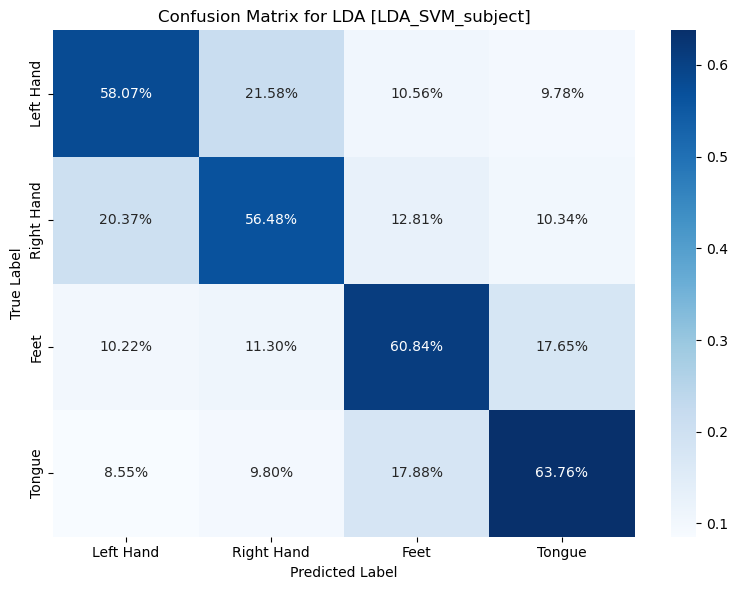

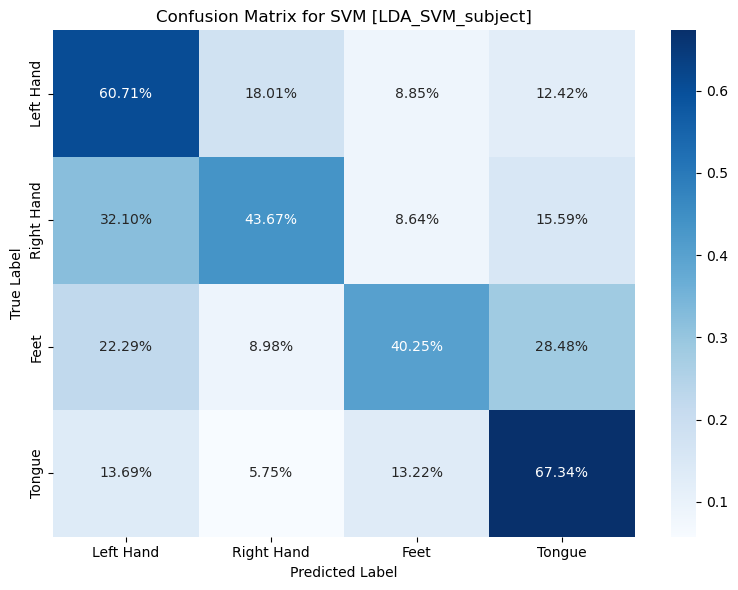

Warning! 'rf_pred' not found in config: LDA_SVM_subject


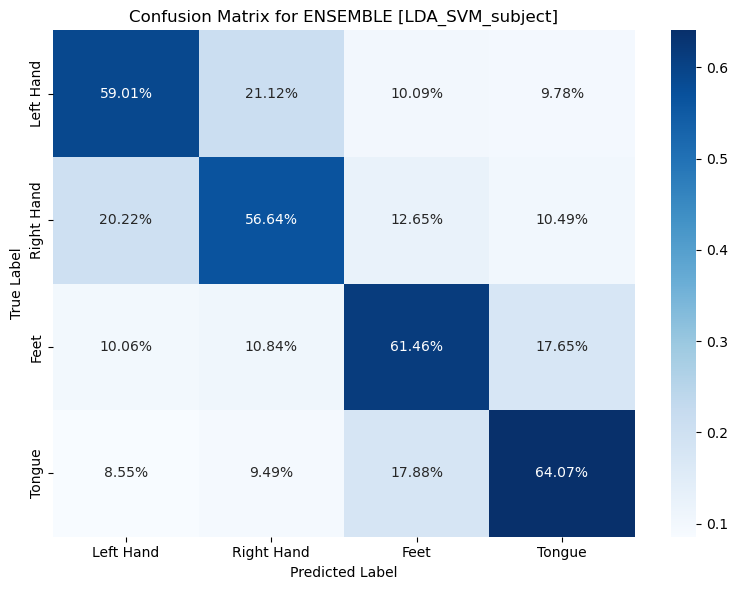

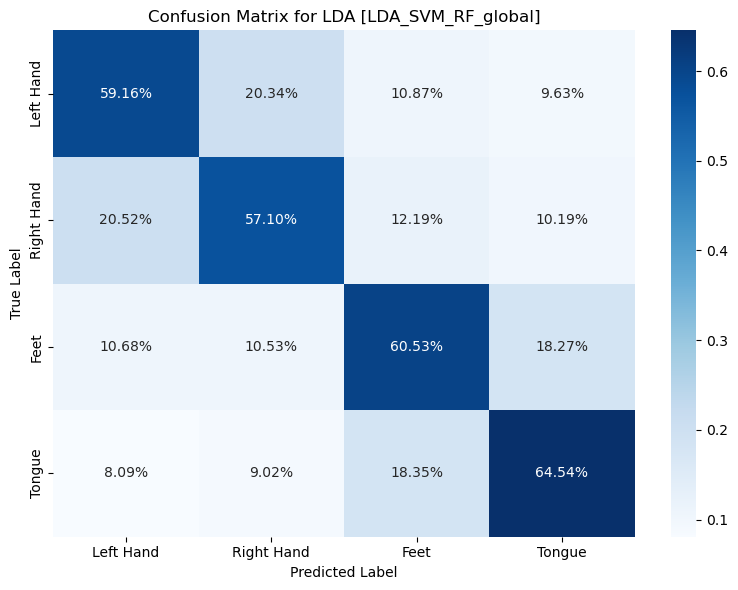

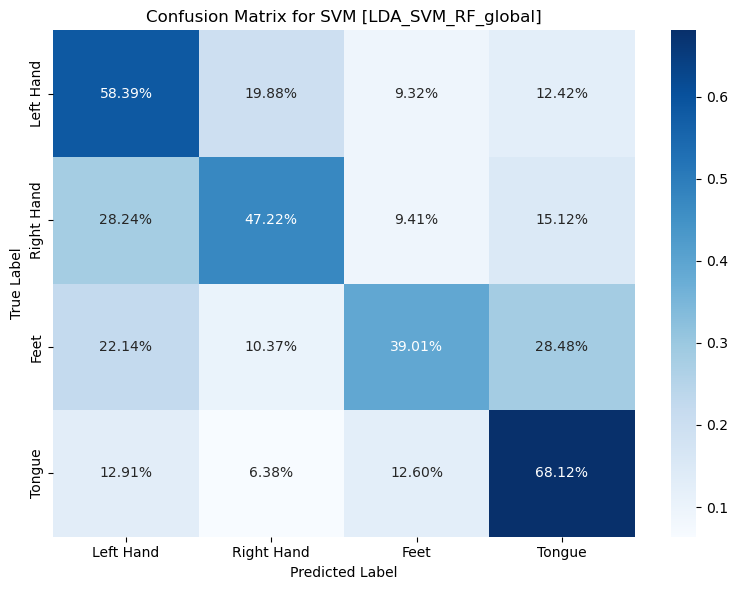

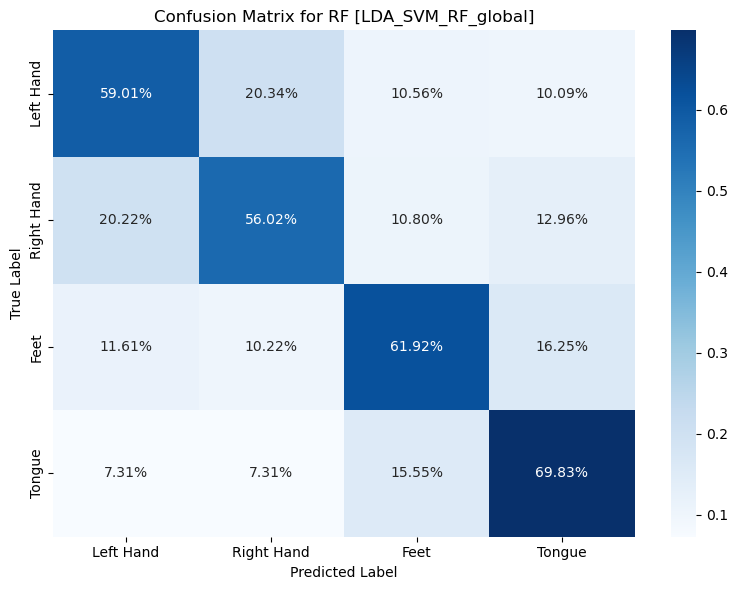

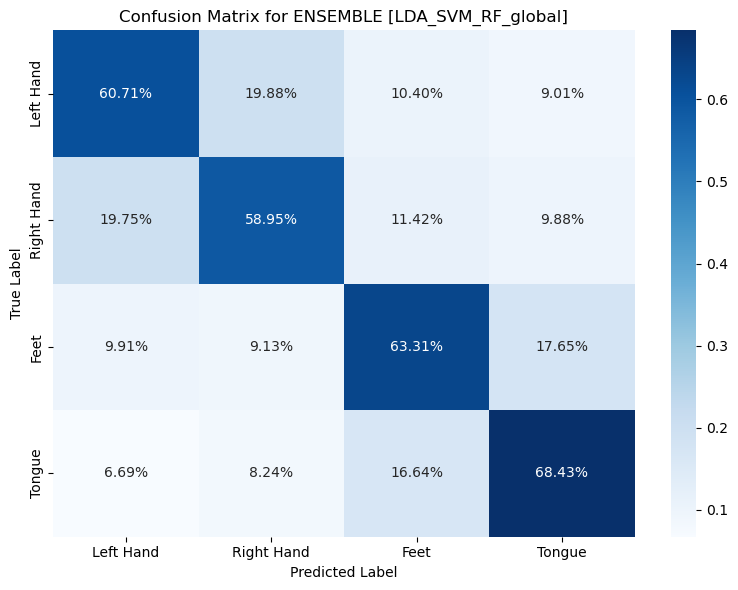

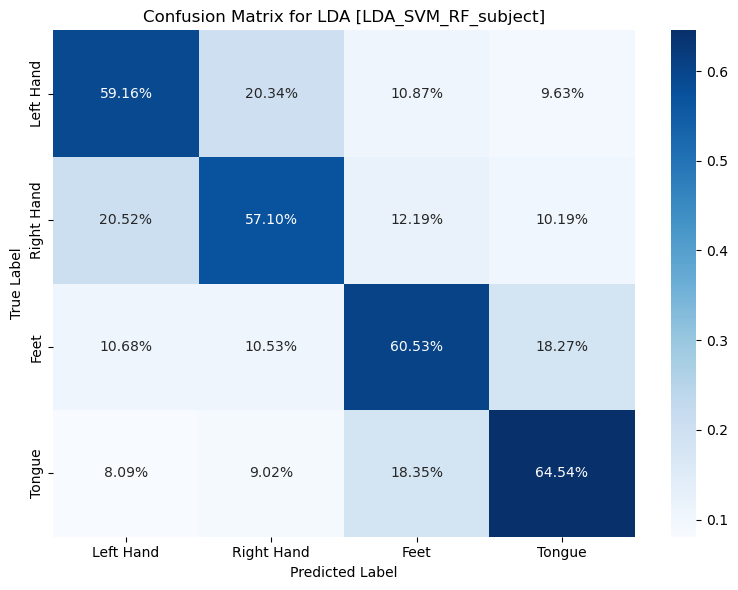

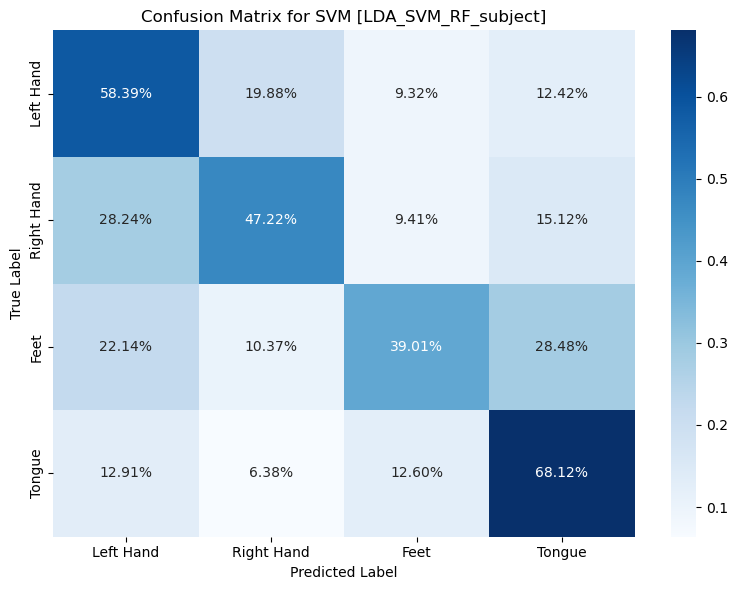

Warning! 'rf_pred' not found in config: LDA_SVM_RF_subject


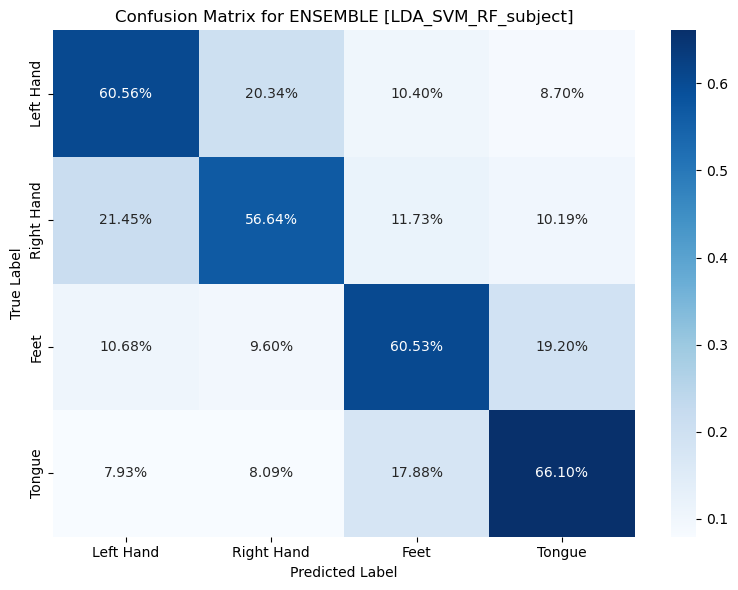

In [21]:
prediction_columns = ['lda_pred', 'svm_pred', 'rf_pred', 'ensemble_pred']

for config_name, df in all_dfs.items():
    if df.empty:
        print(f"Skipping {config_name}: empty DataFrame.")
        continue

    y_true = df['y_true']

    for col in prediction_columns:
        if col in df.columns:
            y_pred = df[col]
            plot_confusion_matrix(
                y_true,
                y_pred,
                class_labels,
                f'Confusion Matrix for {col.replace("_pred", "").upper()} [{config_name}]',
                f'confusion_matrix_{col}_{config_name}.png'
            )
        else:
            print(f"Warning! '{col}' not found in config: {config_name}")

## Calculate Per-Subject Accuracy and Plot

In [22]:
from sklearn.metrics import accuracy_score

prediction_columns = ['lda_pred', 'svm_pred', 'rf_pred', 'ensemble_pred']
accuracy_dfs = {}  # store one accuracy_df per config

for config_name, df in all_dfs.items():
    unique_subjects = df['subject'].unique()
    model_acc = {}

    # only keep columns that exist and are not all NaN for this config
    valid_cols = [
        col for col in prediction_columns
        if col in df.columns and df[col].notna().any()
    ]

    for subject_id in unique_subjects:
        subject_df = df[df['subject'] == subject_id]
        y_true_subject = subject_df['y_true']

        model_acc[subject_id] = {}
        for col in valid_cols:
            y_pred_subject = subject_df[col]
            accuracy = accuracy_score(y_true_subject, y_pred_subject)
            model_acc[subject_id][col.replace('_pred', '')] = accuracy

    accuracy_df = pd.DataFrame.from_dict(model_acc, orient='index')
    accuracy_df.index.name = 'subject'
    accuracy_df.reset_index(inplace=True)

    accuracy_dfs[config_name] = accuracy_df

    print(f"\n── {config_name} ──")
    display(accuracy_df.head())


── LDA_SVM_subject ──


,subject,lda,svm,ensemble
0,1,0.708333,0.677083,0.711806
1,2,0.520833,0.538194,0.527778
2,3,0.732639,0.659722,0.739583
3,4,0.531250,0.361111,0.527778
4,5,0.371528,0.329861,0.385417



── LDA_SVM_RF_global ──


,subject,lda,svm,rf,ensemble
0,1,0.697917,0.673611,0.767361,0.732639
1,2,0.520833,0.545139,0.604167,0.541667
2,3,0.718750,0.659722,0.798611,0.770833
3,4,0.541667,0.399306,0.489583,0.534722
4,5,0.416667,0.312500,0.375000,0.434028



── LDA_SVM_RF_subject ──


,subject,lda,svm,ensemble
0,1,0.697917,0.673611,0.704861
1,2,0.520833,0.545139,0.538194
2,3,0.718750,0.659722,0.739583
3,4,0.541667,0.399306,0.520833
4,5,0.416667,0.312500,0.409722


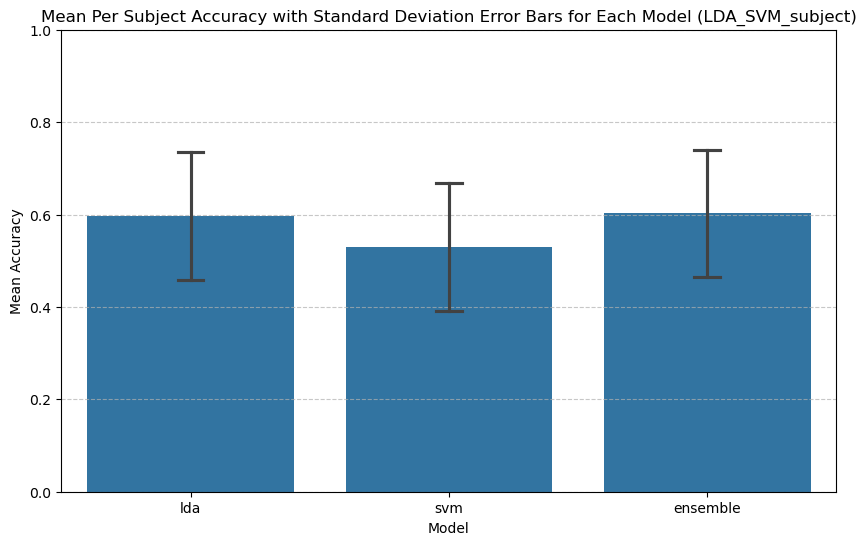

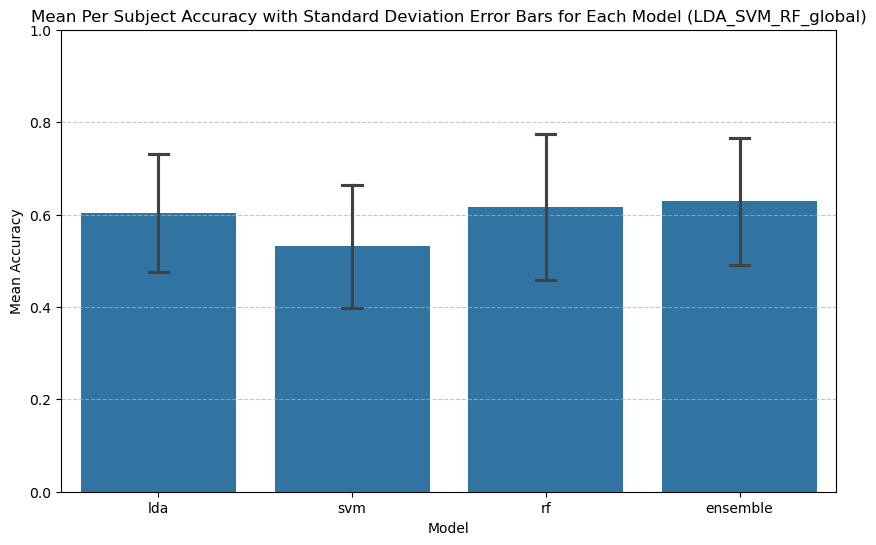

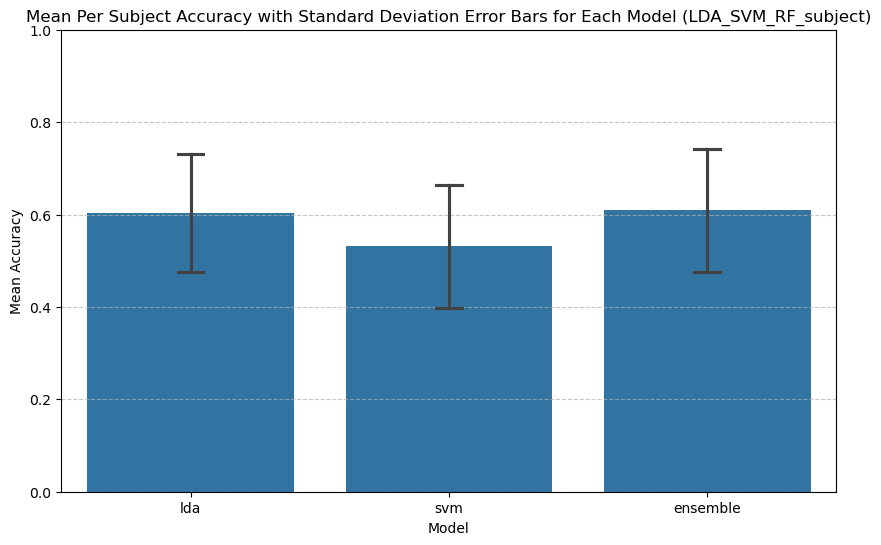

In [23]:
idx = 0
# Melt DataFrame to long format for seaborn barplot
for df in accuracy_dfs.values():
    accuracy_df = df
    accuracy_melted = accuracy_df.melt(
        id_vars=['subject'],
        var_name='model',
        value_name='accuracy'
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='model',
        y='accuracy',
        data=accuracy_melted,
        capsize=.1,
        errorbar='sd'
    )
    plt.title('Mean Per Subject Accuracy with Standard Deviation Error Bars for Each Model (' + list(accuracy_dfs.keys())[idx] + ')')
    plt.xlabel('Model')
    plt.ylabel('Mean Accuracy')
    plt.ylim(0, 1)  # Accuracy from 0 to 1
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    os.makedirs('accuracy_plots', exist_ok=True)
    save_path = os.path.join('accuracy_plots', 'model_accuracy_bar_chart.png')
    plt.savefig(save_path)
    plt.show()
    idx+=1

## Load Key Numbers and Generate Formatted Accuracy Table

In [24]:
import os

key_numbers_path = "outputs/key_numbers"

# Load the new CSV files
try:
    key_numbers_per_subject_df = pd.read_csv(
        os.path.join(key_numbers_path, "key_numbers_per_subject.csv")
    )
    display(key_numbers_per_subject_df.head())
except FileNotFoundError:
    print(f"Error: key_numbers_per_subject.csv not found in {os.path.abspath(key_numbers_path)}.")
except Exception as e:
    print(f"Error loading key_numbers_per_subject.csv: {e}")

try:
    key_numbers_summary_df = pd.read_csv(
        os.path.join(key_numbers_path, "key_numbers_summary.csv")
    )
    display(key_numbers_summary_df.head())
except FileNotFoundError:
    print(f"Error: key_numbers_summary.csv not found in {os.path.abspath(key_numbers_path)}.")
except Exception as e:
    print(f"Error loading key_numbers_summary.csv: {e}")

# Use the same accuracy_df you chose above,
# e.g. accuracy_df = accuracy_dfs["LDA_SVM_RF_global"]

formatted_accuracy_table = accuracy_df.set_index('subject').copy()

# Calculate mean and standard deviation for each model
mean_accuracies = formatted_accuracy_table.mean().rename('Mean')
std_accuracies = formatted_accuracy_table.std().rename('Std Dev')

# Append mean and standard deviation rows
formatted_accuracy_table = pd.concat(
    [formatted_accuracy_table, pd.DataFrame([mean_accuracies, std_accuracies])]
)

# Format for better display
formatted_accuracy_table = formatted_accuracy_table.map(lambda x: f'{x:.4f}')

display(formatted_accuracy_table)

,Subject,LDA Acc,SVM Acc,RF Acc,Best Single,Best Single Acc,LDA_SVM_RF_global_grid Conf Acc @ 0.6,LDA_SVM_RF_global_grid Coverage @ 0.6,LDA_SVM_RF_global_grid (Conf - Best) @ 0.6,LDA_SVM_baseline_subject_grid Conf Acc @ 0.6,LDA_SVM_baseline_subject_grid Coverage @ 0.6,LDA_SVM_baseline_subject_grid (Conf - Best) @ 0.6,Main: LDA+SVM (equal) Conf Acc @ 0.6,Main: LDA+SVM (equal) Coverage @ 0.6,Main: LDA+SVM (equal) (Conf - Best) @ 0.6,Stacking Conf Acc @ 0.6,Stacking Coverage @ 0.6,Stacking (Conf - Best) @ 0.6
0,S1,0.680218,0.489837,0.770720,RF,0.770720,0.803571,0.777778,0.032852,0.782051,0.812500,0.011331,0.798206,0.774306,0.027486,0.779817,0.756944,0.009097
1,S2,0.517120,0.416939,0.576225,RF,0.576225,0.875000,0.305556,0.298775,0.861111,0.375000,0.284886,0.781955,0.461806,0.205730,0.789474,0.329861,0.213249
2,S3,0.725469,0.448336,0.787840,RF,0.787840,0.856502,0.774306,0.068662,0.843478,0.798611,0.055638,0.842553,0.815972,0.054713,0.823276,0.805556,0.035436
3,S4,0.517423,0.337084,0.437447,LDA,0.517423,NaN,0.000000,NaN,0.500000,0.006944,-0.017423,0.380952,0.072917,-0.136470,0.666667,0.145833,0.149244
4,S5,0.402359,0.298972,0.399335,LDA,0.402359,NaN,0.000000,NaN,0.833333,0.020833,0.430974,0.833333,0.020833,0.430974,0.000000,0.003472,-0.402359


,Metric,Value
0,Mean LDA accuracy,0.602216
1,SD LDA accuracy (across subjects),0.134329
2,Mean SVM accuracy,0.389217
3,SD SVM accuracy (across subjects),0.084198
4,Mean RF accuracy,0.611517


,lda,svm,ensemble
1,0.6979,0.6736,0.7049
2,0.5208,0.5451,0.5382
3,0.7188,0.6597,0.7396
4,0.5417,0.3993,0.5208
5,0.4167,0.3125,0.4097
6,0.4826,0.4132,0.4757
7,0.7569,0.6389,0.7535
8,0.7465,0.6424,0.7639
9,0.5451,0.4982,0.5776
Mean,0.6030,0.5314,0.6093


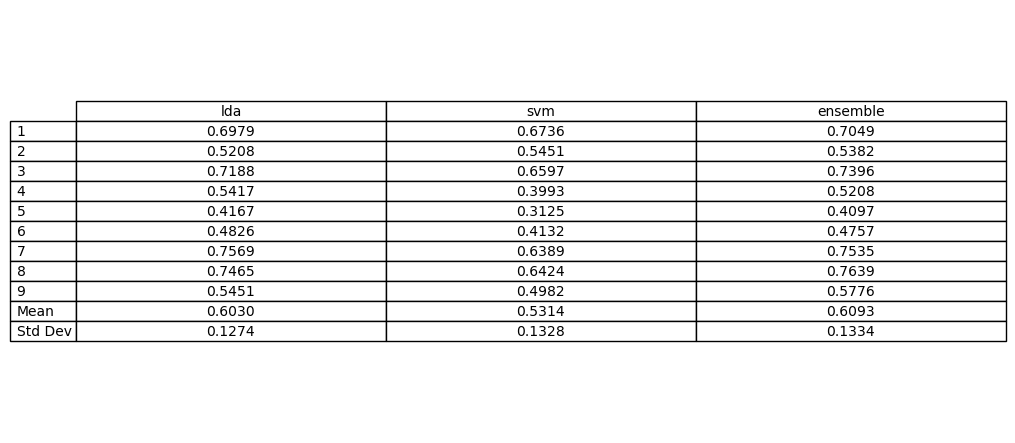

In [25]:
import matplotlib.pyplot as plt
from pandas.plotting import table

# Save the formatted table as CSV
csv_save_path = os.path.join('accuracy_plots', 'formatted_accuracy_table.csv')
formatted_accuracy_table.to_csv(csv_save_path)

# Save the formatted table as PNG
fig, ax = plt.subplots(figsize=(10, len(formatted_accuracy_table) * 0.5))
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

tbl = table(ax, formatted_accuracy_table, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)

png_save_path = os.path.join('accuracy_plots', 'formatted_accuracy_table.png')
plt.savefig(png_save_path, bbox_inches='tight', pad_inches=0.5)
plt.show()


## Statistical Analysis: Paired t-test

In [26]:
from scipy import stats

# Work directly on the key_numbers_per_subject_df that you loaded from CSV
df_kn = key_numbers_per_subject_df.copy()

# Sanity: ensure numeric
cols_needed = [
    'Best Single Acc',
    'LDA_SVM_RF_global_grid Conf Acc @ 0.6',
    'LDA_SVM_baseline_subject_grid Conf Acc @ 0.6',
]
df_kn[cols_needed] = df_kn[cols_needed].astype(float)

best_single = df_kn['Best Single Acc']

def run_tests(label, conf_col):
    conf_scores = df_kn[conf_col]

    # Paired t-test (same subjects under two methods)
    t_stat, p_val = stats.ttest_rel(conf_scores, best_single)

    # Levene’s test for equal variances
    lev_stat, lev_p = stats.levene(conf_scores, best_single, center='mean')  # mean-centred is standard for normals[web:45][web:51]

    print(f"\n=== {label} @ 0.6 ===")
    print("Paired t-test (Conf Acc vs Best Single Acc)")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {p_val:.4f}")

    alpha = 0.05
    if p_val < alpha:
        print(f"  → p ({p_val:.4f}) < α ({alpha}) ⇒ reject H₀ (means differ).")
        if t_stat > 0:
            print("  → Conf Acc significantly HIGHER than Best Single.")
        else:
            print("  → Conf Acc significantly LOWER than Best Single.")
    else:
        print(f"  → p ({p_val:.4f}) ≥ α ({alpha}) ⇒ fail to reject H₀ (no sig. difference).")

    print("\nLevene's test (variance equality)")
    print(f"  statistic:   {lev_stat:.4f}")
    print(f"  p-value:     {lev_p:.4f}")
    if lev_p < alpha:
        print("  → Variances differ (no homoscedasticity).")
    else:
        print("  → No evidence variances differ (homoscedastic).")

# Run for both ensemble configs
run_tests(
    "LDA_SVM_RF_global_grid",
    "LDA_SVM_RF_global_grid Conf Acc @ 0.6"
)

run_tests(
    "LDA_SVM_baseline_subject_grid",
    "LDA_SVM_baseline_subject_grid Conf Acc @ 0.6"
)

run_tests(
    "Main: LDA+SVM (equal)",
    "Main: LDA+SVM (equal) Conf Acc @ 0.6"
)


# Optional: also for Main equal-weight ensemble
# run_tests(
#     "Main: LDA+SVM (equal)",
#     "Main: LDA+SVM (equal) Conf Acc @ 0.6"
# )


=== LDA_SVM_RF_global_grid @ 0.6 ===
Paired t-test (Conf Acc vs Best Single Acc)
  t-statistic: nan
  p-value:     nan
  → p (nan) ≥ α (0.05) ⇒ fail to reject H₀ (no sig. difference).

Levene's test (variance equality)
  statistic:   nan
  p-value:     nan
  → No evidence variances differ (homoscedastic).

=== LDA_SVM_baseline_subject_grid @ 0.6 ===
Paired t-test (Conf Acc vs Best Single Acc)
  t-statistic: 2.5184
  p-value:     0.0359
  → p (0.0359) < α (0.05) ⇒ reject H₀ (means differ).
  → Conf Acc significantly HIGHER than Best Single.

Levene's test (variance equality)
  statistic:   0.9971
  p-value:     0.3329
  → No evidence variances differ (homoscedastic).

=== Main: LDA+SVM (equal) @ 0.6 ===
Paired t-test (Conf Acc vs Best Single Acc)
  t-statistic: 1.3193
  p-value:     0.2236
  → p (0.2236) ≥ α (0.05) ⇒ fail to reject H₀ (no sig. difference).

Levene's test (variance equality)
  statistic:   0.1126
  p-value:     0.7415
  → No evidence variances differ (homoscedastic).


In [27]:
from scipy import stats

df_kn = key_numbers_per_subject_df.copy()

best_single = df_kn['Best Single Acc']
conf_global  = df_kn['LDA_SVM_RF_global_grid Conf Acc @ 0.6']
conf_subject = df_kn['LDA_SVM_baseline_subject_grid Conf Acc @ 0.6']

def run_tests(label, conf_scores):
    # Drop any subjects where either side is NaN
    mask = conf_scores.notna() & best_single.notna()
    x = conf_scores[mask]
    y = best_single[mask]

    t_stat, p_val   = stats.ttest_rel(x, y)                        # paired t‑test[web:44]
    lev_stat, lev_p = stats.levene(x, y, center='mean')            # Levene’s test[web:45]

    print(f"\n=== {label} @ 0.6 ===")
    print("Paired t-test (Conf Acc vs Best Single Acc)")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {p_val:.4f}")

    print("\nLevene's test (variance equality)")
    print(f"  statistic:   {lev_stat:.4f}")
    print(f"  p-value:     {lev_p:.4f}")

    alpha = 0.05
    if p_val < alpha:
        print(f"\nConclusion (t-test): p ({p_val:.4f}) < α ({alpha}) → reject H₀.")
        if t_stat > 0:
            print("  Conf Acc significantly HIGHER than Best Single.")
        else:
            print("  Conf Acc significantly LOWER than Best Single.")
    else:
        print(f"\nConclusion (t-test): p ({p_val:.4f}) ≥ α ({alpha}) → fail to reject H₀.")

    if lev_p < alpha:
        print("Conclusion (Levene): variances differ (no homoscedasticity).")
    else:
        print("Conclusion (Levene): no evidence variances differ (homoscedastic).")

# Global grid (drops S4,S5 where conf acc is missing)
run_tests("LDA_SVM_RF_global_grid", conf_global)

# Baseline subject grid (already matches your summary)
run_tests("LDA_SVM_baseline_subject_grid", conf_subject)


=== LDA_SVM_RF_global_grid @ 0.6 ===
Paired t-test (Conf Acc vs Best Single Acc)
  t-statistic: 2.9864
  p-value:     0.0244

Levene's test (variance equality)
  statistic:   2.1024
  p-value:     0.1727

Conclusion (t-test): p (0.0244) < α (0.05) → reject H₀.
  Conf Acc significantly HIGHER than Best Single.
Conclusion (Levene): no evidence variances differ (homoscedastic).

=== LDA_SVM_baseline_subject_grid @ 0.6 ===
Paired t-test (Conf Acc vs Best Single Acc)
  t-statistic: 2.5184
  p-value:     0.0359

Levene's test (variance equality)
  statistic:   0.9971
  p-value:     0.3329

Conclusion (t-test): p (0.0359) < α (0.05) → reject H₀.
  Conf Acc significantly HIGHER than Best Single.
Conclusion (Levene): no evidence variances differ (homoscedastic).
